## PROCESAMIENTO DE DATOS

Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


In [2]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed_diversified"
RESULTS_DIR = PROJECT_ROOT / "results" / "eda_diversified"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PRICES_FILE = DATA_DIR / "adjusted_prices.csv"
returns_clean_FILE = DATA_DIR / "daily_returns.csv"
SECTOR_MAP_FILE = DATA_DIR / "sector_map.csv"

print("Directorio de datos:", DATA_DIR)
print("Directorio de resultados:", RESULTS_DIR)


Directorio de datos: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\data\processed_diversified
Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\eda_diversified


In [3]:
prices = pd.read_csv(
    PRICES_FILE,
    index_col=0,
    parse_dates=True
)

returns = pd.read_csv(
    returns_clean_FILE,
    index_col=0,
    parse_dates=True
)

prices.index.name = "Date"
returns.index.name = "Date"

print("Precios:", prices.shape)
print("Retornos:", returns.shape)

Precios: (2198, 45)
Retornos: (2198, 45)


### Mapeo de sectores

A diferencia del universo original (concentrado en tecnológicas), aquí cada activo pertenece a uno de 11 sectores GICS. Se carga el mapeo generado por `data_pipeline_diversified.py` y se arma una paleta de colores por sector, para que las gráficas con muchos activos (44 en total) se puedan leer agrupadas por sector en vez de con una leyenda de 44 líneas individuales.

In [4]:
sector_map = pd.read_csv(SECTOR_MAP_FILE)
ticker_to_sector = dict(zip(sector_map["ticker"], sector_map["sector"]))

sectors = sorted(sector_map["sector"].unique())
cmap = plt.get_cmap("tab20")
sector_to_color = {sector: cmap(i / len(sectors)) for i, sector in enumerate(sectors)}

print("Sectores:", len(sectors))
sector_map.groupby("sector")["ticker"].apply(list)


Sectores: 11


sector
Bienes Raíces                   [PLD, AMT, EQIX, SPG]
Consumo Básico                     [WMT, PG, KO, PEP]
Consumo Discrecional            [AMZN, TSLA, HD, MCD]
Energía                          [XOM, CVX, COP, SLB]
Financiero                          [JPM, V, MA, BAC]
Industrial                        [CAT, GE, HON, UNP]
Materiales                       [LIN, SHW, APD, ECL]
Salud                           [LLY, UNH, JNJ, ABBV]
Servicios Públicos                  [NEE, DUK, SO, D]
Servicios de Comunicación    [GOOGL, META, NFLX, DIS]
Tecnología                   [AAPL, MSFT, NVDA, AVGO]
Name: ticker, dtype: object

## Revisamos los datos

In [5]:
prices.head()

,AAPL,ABBV,AMT,AMZN,APD,AVGO,BAC,CAT,COP,CVX,...,SLB,SO,SPG,TSLA,UNH,UNP,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.232372,68.287102,112.758125,59.450500,134.556656,21.015070,24.385727,131.050781,41.763916,87.873604,...,54.367905,33.138985,108.204880,21.368668,190.818909,112.165863,107.688179,28.731449,57.811157,2695.810059
2018-01-03,40.225380,69.355698,113.197510,60.209999,135.288361,21.244888,24.304173,131.251068,42.533970,88.514168,...,55.783432,32.949291,107.702805,21.150000,192.820602,112.793671,108.760277,28.982080,58.946560,2713.060059
2018-01-04,40.412220,68.960197,111.543663,60.479500,135.808609,21.251976,24.622242,133.053619,43.024685,88.238655,...,57.167648,32.808781,104.552460,20.974667,193.657578,112.182426,109.164665,29.008307,59.028152,2723.989990
2018-01-05,40.872330,70.160629,112.262772,61.457001,136.946808,21.377907,24.736423,135.156570,42.941650,88.094025,...,57.558651,32.864979,105.525169,21.105333,197.350388,113.611465,111.779045,29.180241,58.980576,2743.149902
2018-01-08,40.720512,69.036522,113.461166,62.343498,137.093140,21.429062,24.565151,138.552948,43.379517,88.527931,...,58.497143,33.160069,106.215500,22.427334,193.924973,115.189323,112.230453,29.611551,59.245716,2747.709961


In [6]:
returns.head()

,AAPL,ABBV,AMT,AMZN,APD,AVGO,BAC,CAT,COP,CVX,...,SLB,SO,SPG,TSLA,UNH,UNP,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,-0.000174,0.015649,0.003897,0.012775,0.005438,0.010936,-0.003344,0.001528,0.018438,0.007290,...,0.026036,-0.005724,-0.004640,-0.010233,0.010490,0.005597,0.009956,0.008723,0.019640,0.006399
2018-01-04,0.004645,-0.005702,-0.014610,0.004476,0.003845,0.000334,0.013087,0.013734,0.011537,-0.003113,...,0.024814,-0.004264,-0.029250,-0.008290,0.004341,-0.005419,0.003718,0.000905,0.001384,0.004029
2018-01-05,0.011385,0.017408,0.006447,0.016163,0.008381,0.005926,0.004637,0.015805,-0.001930,-0.001639,...,0.006840,0.001713,0.009304,0.006230,0.019069,0.012739,0.023949,0.005927,-0.000806,0.007034
2018-01-08,-0.003714,-0.016022,0.010675,0.014425,0.001069,0.002393,-0.006924,0.025129,0.010197,0.004925,...,0.016305,0.008979,0.006542,0.062638,-0.017357,0.013888,0.004038,0.014781,0.004495,0.001662


In [7]:
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2198 entries, 2018-01-02 to 2026-09-30
Data columns (total 45 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2198 non-null   float64
 1   ABBV    2198 non-null   float64
 2   AMT     2198 non-null   float64
 3   AMZN    2198 non-null   float64
 4   APD     2198 non-null   float64
 5   AVGO    2198 non-null   float64
 6   BAC     2198 non-null   float64
 7   CAT     2198 non-null   float64
 8   COP     2198 non-null   float64
 9   CVX     2198 non-null   float64
 10  D       2198 non-null   float64
 11  DIS     2198 non-null   float64
 12  DUK     2198 non-null   float64
 13  ECL     2198 non-null   float64
 14  EQIX    2198 non-null   float64
 15  GE      2198 non-null   float64
 16  GOOGL   2198 non-null   float64
 17  HD      2198 non-null   float64
 18  HON     2198 non-null   float64
 19  JNJ     2198 non-null   float64
 20  JPM     2198 non-null   float64
 21  KO      2198 non-null   float6

In [8]:
returns.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2198 entries, 2018-01-02 to 2026-09-30
Data columns (total 45 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2197 non-null   float64
 1   ABBV    2197 non-null   float64
 2   AMT     2197 non-null   float64
 3   AMZN    2197 non-null   float64
 4   APD     2197 non-null   float64
 5   AVGO    2197 non-null   float64
 6   BAC     2197 non-null   float64
 7   CAT     2197 non-null   float64
 8   COP     2197 non-null   float64
 9   CVX     2197 non-null   float64
 10  D       2197 non-null   float64
 11  DIS     2197 non-null   float64
 12  DUK     2197 non-null   float64
 13  ECL     2197 non-null   float64
 14  EQIX    2197 non-null   float64
 15  GE      2197 non-null   float64
 16  GOOGL   2197 non-null   float64
 17  HD      2197 non-null   float64
 18  HON     2197 non-null   float64
 19  JNJ     2197 non-null   float64
 20  JPM     2197 non-null   float64
 21  KO      2197 non-null   float6

In [9]:
missing_prices = prices.isna().sum()
missing_returns = returns.isna().sum()

print("Valores faltantes en precios:")
display(missing_prices)

print("\nValores faltantes en retornos:")
display(missing_returns)

Valores faltantes en precios:


AAPL     0
ABBV     0
AMT      0
AMZN     0
APD      0
AVGO     0
BAC      0
CAT      0
COP      0
CVX      0
D        0
DIS      0
DUK      0
ECL      0
EQIX     0
GE       0
GOOGL    0
HD       0
HON      0
JNJ      0
JPM      0
KO       0
LIN      0
LLY      0
MA       0
MCD      0
META     0
MSFT     0
NEE      0
NFLX     0
NVDA     0
PEP      0
PG       0
PLD      0
SHW      0
SLB      0
SO       0
SPG      0
TSLA     0
UNH      0
UNP      0
V        0
WMT      0
XOM      0
^GSPC    0
dtype: int64


Valores faltantes en retornos:


AAPL     1
ABBV     1
AMT      1
AMZN     1
APD      1
AVGO     1
BAC      1
CAT      1
COP      1
CVX      1
D        1
DIS      1
DUK      1
ECL      1
EQIX     1
GE       1
GOOGL    1
HD       1
HON      1
JNJ      1
JPM      1
KO       1
LIN      1
LLY      1
MA       1
MCD      1
META     1
MSFT     1
NEE      1
NFLX     1
NVDA     1
PEP      1
PG       1
PLD      1
SHW      1
SLB      1
SO       1
SPG      1
TSLA     1
UNH      1
UNP      1
V        1
WMT      1
XOM      1
^GSPC    1
dtype: int64

In [10]:
returns_clean = returns.dropna(how="all")
prices_clean = prices.loc[returns_clean.index]

## Estadísticas descriptivas


In [11]:
descriptive_stats = returns_clean.describe().T

descriptive_stats



,count,mean,std,min,25%,50%,75%,max
AAPL,2197.0,0.001146,0.019189,-0.128647,-0.007907,0.001187,0.010940,0.153289
ABBV,2197.0,0.000754,0.016816,-0.162524,-0.007069,0.001085,0.009184,0.137673
AMT,2197.0,0.000320,0.017337,-0.151638,-0.008477,0.000703,0.009396,0.122219
AMZN,2197.0,0.000887,0.021705,-0.140494,-0.010431,0.000909,0.012302,0.153206
APD,2197.0,0.000480,0.017233,-0.155518,-0.007799,0.000759,0.008564,0.137233
AVGO,2197.0,0.001626,0.026247,-0.199129,-0.011346,0.001388,0.014230,0.244326
BAC,2197.0,0.000561,0.019794,-0.153973,-0.008898,0.000651,0.010234,0.177962
CAT,2197.0,0.001042,0.020583,-0.142822,-0.009723,0.000879,0.012248,0.116346
COP,2197.0,0.000802,0.024553,-0.248401,-0.011237,0.000424,0.013373,0.252138
CVX,2197.0,0.000574,0.019438,-0.221248,-0.008021,0.000984,0.009391,0.227407


In [12]:
stats = pd.DataFrame(index=returns_clean.columns)

stats["Mean Daily Return"] = returns_clean.mean()

stats["Daily Volatility"] = returns_clean.std()

stats["Annualized Return"] = returns_clean.mean() * 252

stats["Annualized Volatility"] = returns_clean.std() * np.sqrt(252)

stats["Minimum Daily Return"] = returns_clean.min()

stats["Maximum Daily Return"] = returns_clean.max()

stats["Skewness"] = returns_clean.skew()

stats["Kurtosis"] = returns_clean.kurtosis()

stats = stats.sort_values(
    "Annualized Return",
    ascending=False
)

stats.round(4)

,Mean Daily Return,Daily Volatility,Annualized Return,Annualized Volatility,Minimum Daily Return,Maximum Daily Return,Skewness,Kurtosis
NVDA,0.0022,0.0317,0.5669,0.5030,-0.1876,0.2437,0.1424,4.8638
TSLA,0.0020,0.0393,0.5159,0.6235,-0.2106,0.2269,0.2758,3.8187
AVGO,0.0016,0.0262,0.4099,0.4167,-0.1991,0.2443,0.2254,9.9206
LLY,0.0014,0.0201,0.3645,0.3184,-0.1414,0.1568,0.7848,9.9019
AAPL,0.0011,0.0192,0.2889,0.3046,-0.1286,0.1533,0.1148,6.3064
GOOGL,0.0010,0.0196,0.2626,0.3109,-0.1163,0.1022,0.0484,3.8309
CAT,0.0010,0.0206,0.2625,0.3267,-0.1428,0.1163,-0.0491,3.8938
MSFT,0.0010,0.0183,0.2575,0.2911,-0.1474,0.1551,0.2799,8.2975
META,0.0010,0.0263,0.2479,0.4171,-0.2639,0.2328,-0.2410,16.4722
NFLX,0.0009,0.0268,0.2353,0.4260,-0.3512,0.1685,-0.8581,18.3671


Evaluación de precios

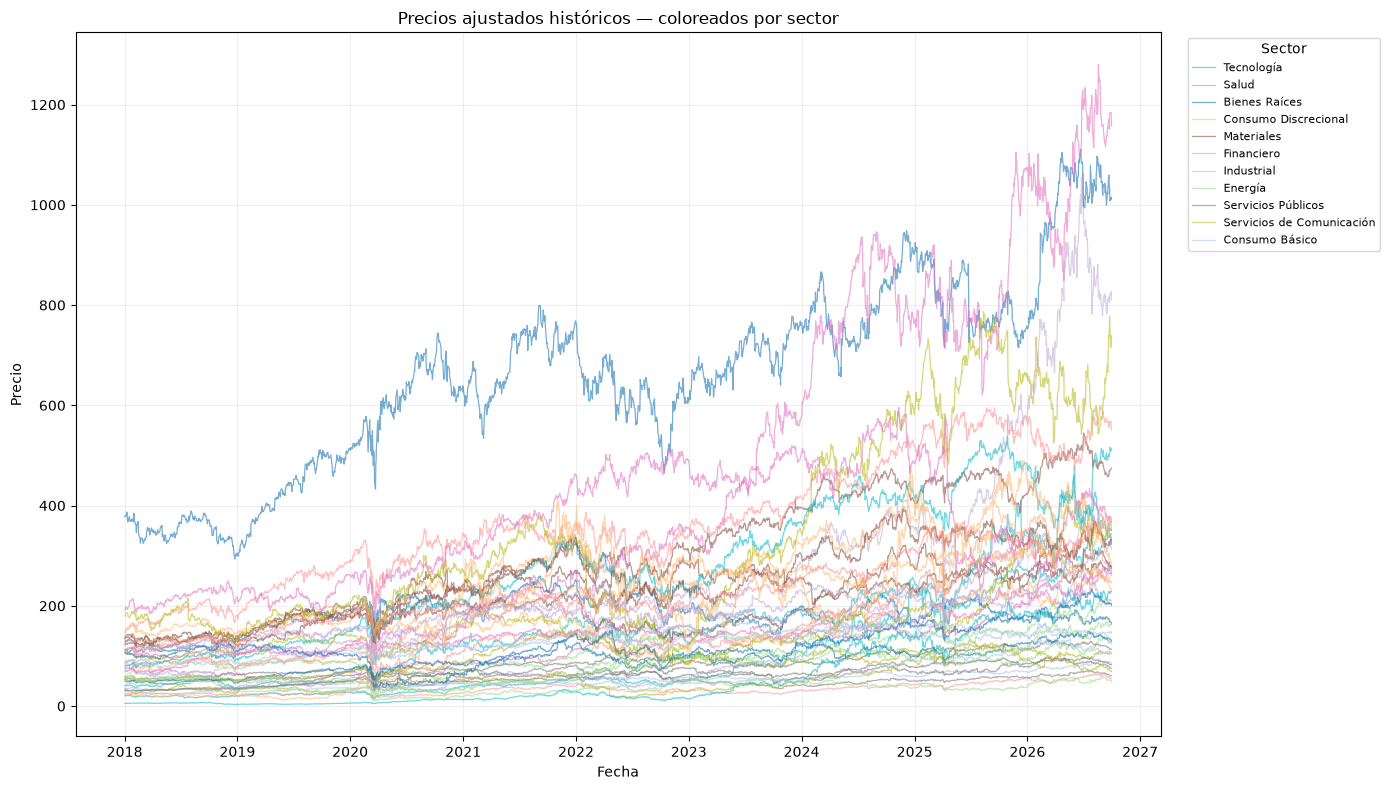

In [13]:
plt.figure(figsize=(14, 8))

plotted_sectors = set()

for ticker in prices.columns:
    if ticker == "^GSPC":
        continue
    sector = ticker_to_sector.get(ticker, "Otro")
    color = sector_to_color.get(sector, "gray")
    label = sector if sector not in plotted_sectors else None
    plotted_sectors.add(sector)
    plt.plot(prices.index, prices[ticker], color=color, alpha=0.6, linewidth=0.9, label=label)

plt.title("Precios ajustados históricos — coloreados por sector")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Sector")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "01_precios_historicos.png", dpi=300, bbox_inches="tight")
plt.show()


### Rendimiento acumulado

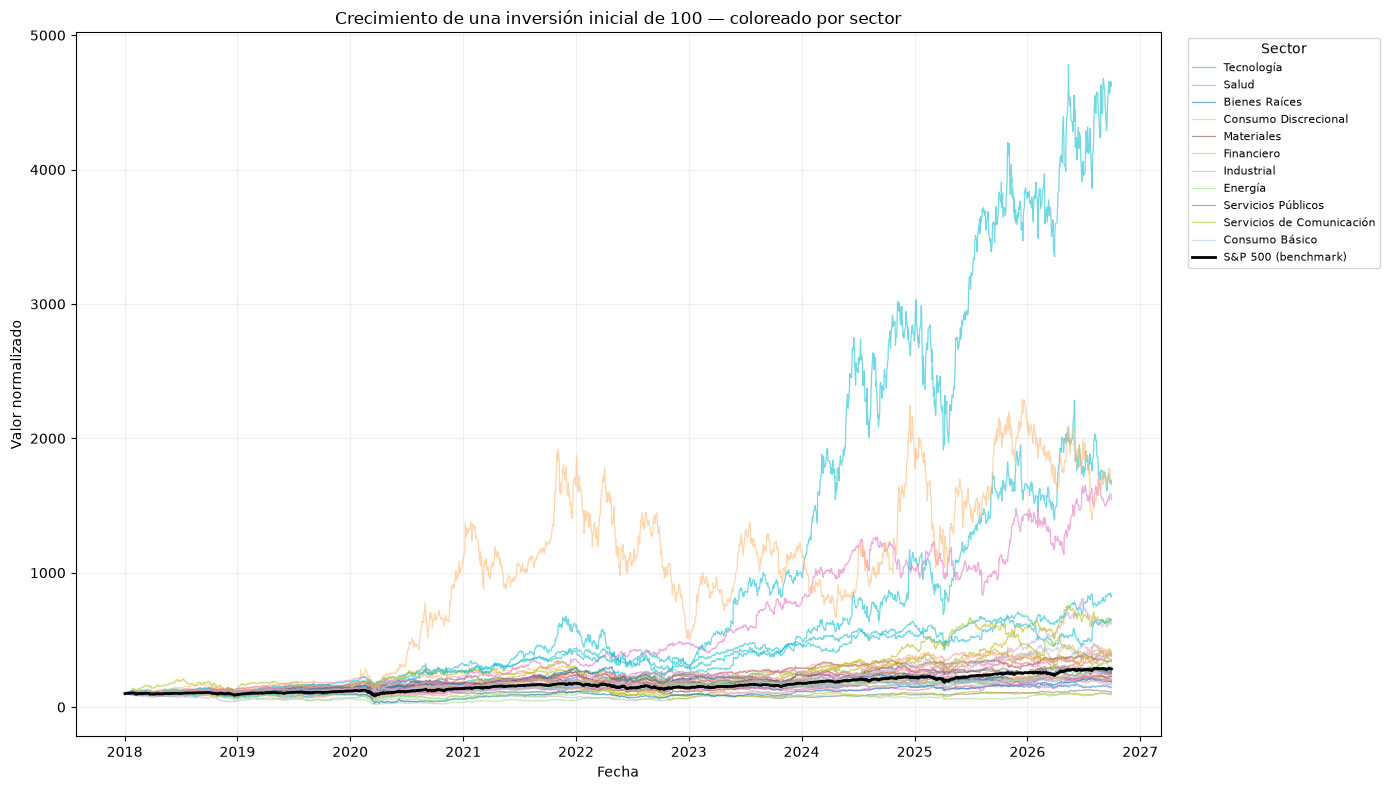

In [14]:
normalized_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(14, 8))

plotted_sectors = set()

for ticker in normalized_prices.columns:
    if ticker == "^GSPC":
        continue
    sector = ticker_to_sector.get(ticker, "Otro")
    color = sector_to_color.get(sector, "gray")
    label = sector if sector not in plotted_sectors else None
    plotted_sectors.add(sector)
    plt.plot(normalized_prices.index, normalized_prices[ticker], color=color, alpha=0.6, linewidth=0.9, label=label)

# El S&P 500 se traza aparte, en negro, para que resalte como referencia
plt.plot(normalized_prices.index, normalized_prices["^GSPC"], color="black", linewidth=2, label="S&P 500 (benchmark)")

plt.title("Crecimiento de una inversión inicial de 100 — coloreado por sector")
plt.xlabel("Fecha")
plt.ylabel("Valor normalizado")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Sector")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "02_rendimiento_acumulado.png", dpi=300, bbox_inches="tight")
plt.show()


Comparación

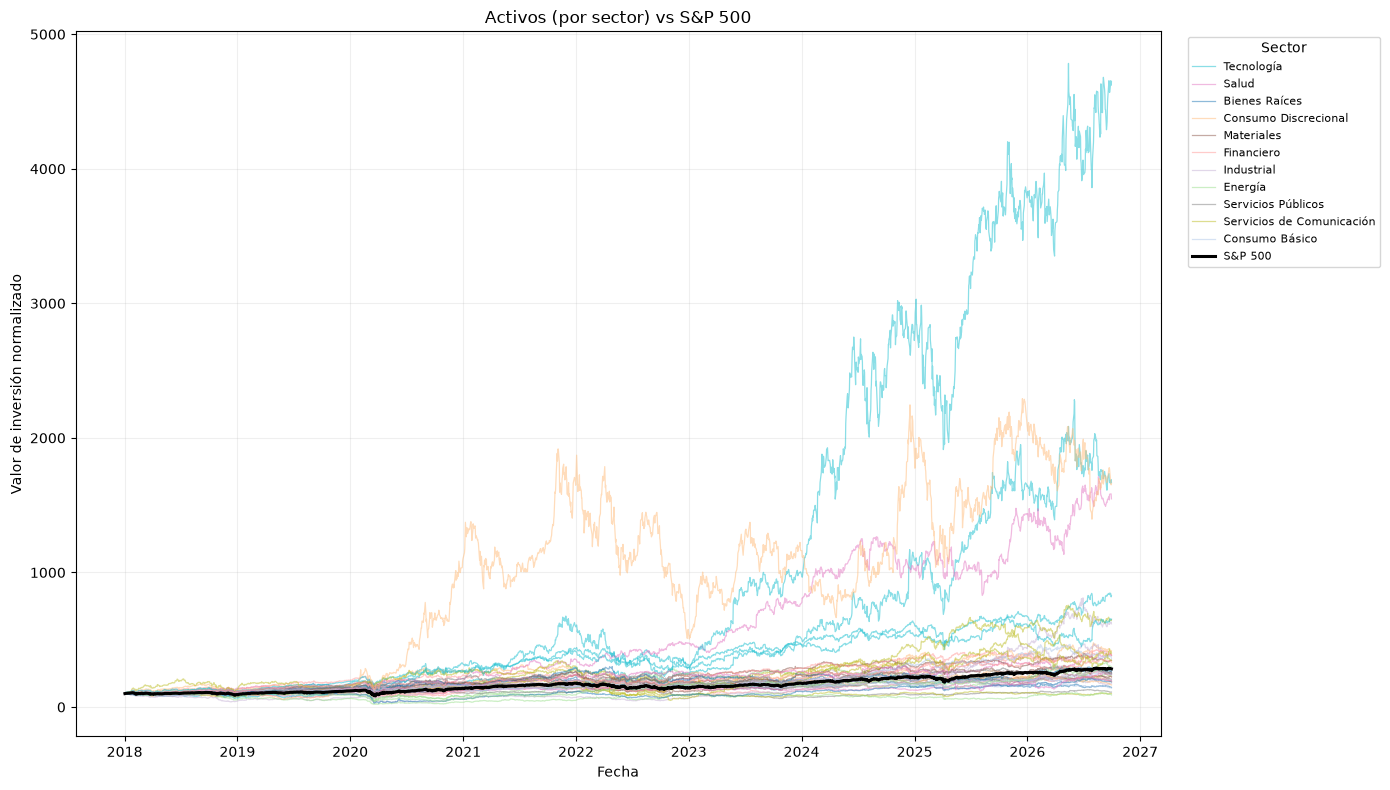

In [15]:
benchmark = "^GSPC"

asset_prices = prices.drop(columns=[benchmark])
asset_returns = returns_clean.drop(columns=[benchmark])

sp500_prices = prices[benchmark]
sp500_returns = returns_clean[benchmark]

normalized_assets = asset_prices / asset_prices.iloc[0] * 100
normalized_sp500 = sp500_prices / sp500_prices.iloc[0] * 100

plt.figure(figsize=(14, 8))

plotted_sectors = set()

for ticker in normalized_assets.columns:
    sector = ticker_to_sector.get(ticker, "Otro")
    color = sector_to_color.get(sector, "gray")
    label = sector if sector not in plotted_sectors else None
    plotted_sectors.add(sector)
    plt.plot(normalized_assets.index, normalized_assets[ticker], color=color, alpha=0.5, linewidth=0.9, label=label)

plt.plot(normalized_sp500.index, normalized_sp500, color="black", linewidth=2.2, label="S&P 500")

plt.title("Activos (por sector) vs S&P 500")
plt.xlabel("Fecha")
plt.ylabel("Valor de inversión normalizado")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Sector")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "03_vs_sp500.png", dpi=300, bbox_inches="tight")
plt.show()


Dist retornos

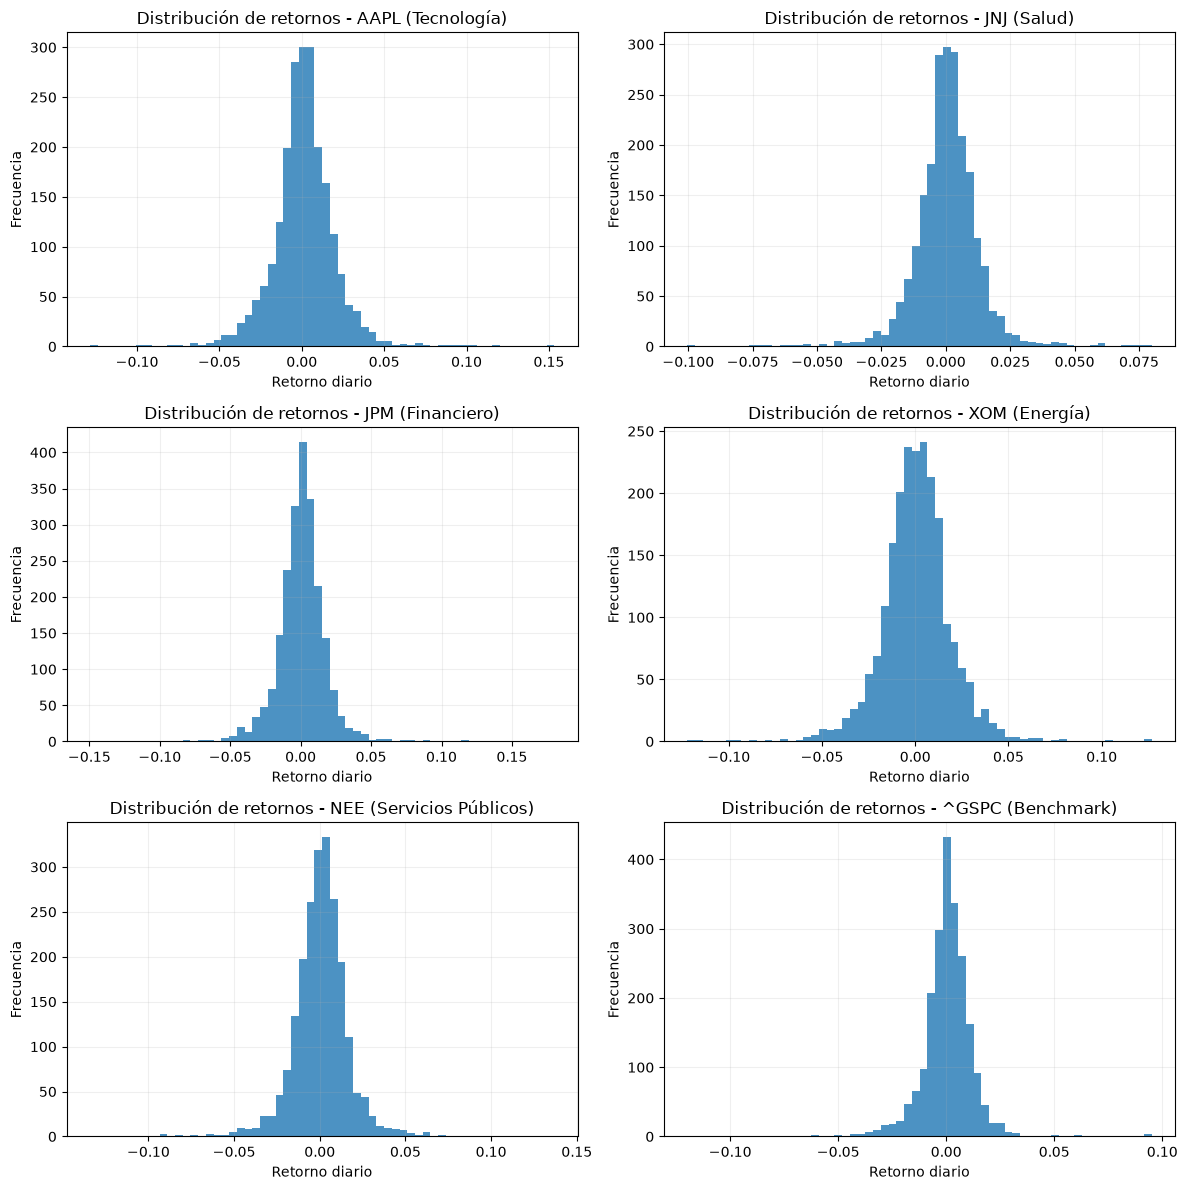

In [16]:
# Un activo representativo de distintos sectores, en vez de solo tecnológicas
selected_assets = [
    "AAPL",   # Tecnología
    "JNJ",    # Salud
    "JPM",    # Financiero
    "XOM",    # Energía
    "NEE",    # Servicios Públicos
    "^GSPC"   # Benchmark
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for ax, ticker in zip(axes.flatten(), selected_assets):

    ax.hist(returns_clean[ticker].dropna(), bins=60, alpha=0.8)

    sector_label = ticker_to_sector.get(ticker, "Benchmark")
    ax.set_title(f"Distribución de retornos - {ticker} ({sector_label})")
    ax.set_xlabel("Retorno diario")
    ax.set_ylabel("Frecuencia")
    ax.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(RESULTS_DIR / "04_distribuciones_retornos.png", dpi=300, bbox_inches="tight")
plt.show()


Volatilidad

In [17]:
rolling_volatility = returns_clean.rolling(
    window=30
).std() * np.sqrt(252)

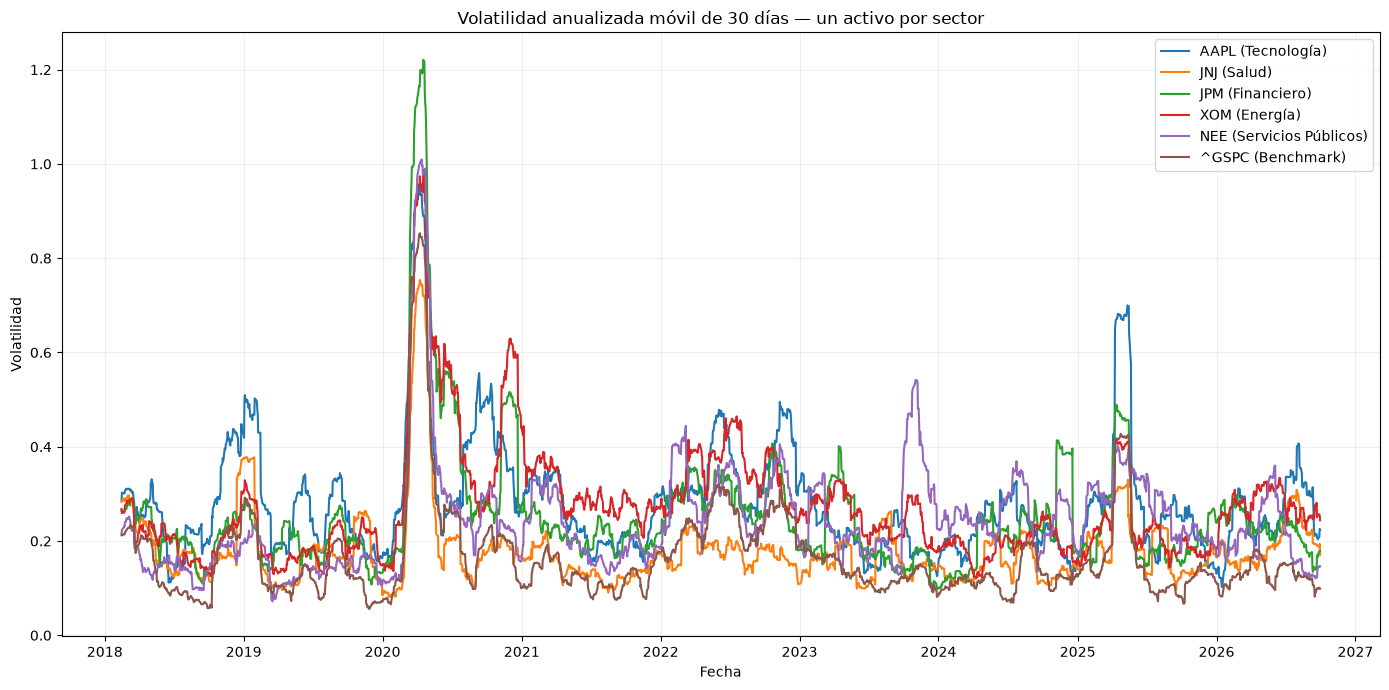

In [18]:
plt.figure(figsize=(14, 7))

for ticker in selected_assets:
    plt.plot(rolling_volatility.index, rolling_volatility[ticker], label=f"{ticker} ({ticker_to_sector.get(ticker, 'Benchmark')})")

plt.title("Volatilidad anualizada móvil de 30 días — un activo por sector")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(RESULTS_DIR / "05_volatilidad_movil.png", dpi=300, bbox_inches="tight")
plt.show()


Matriz de correlación

In [19]:
correlation_matrix = returns_clean.corr()

correlation_matrix.round(2)

,AAPL,ABBV,AMT,AMZN,APD,AVGO,BAC,CAT,COP,CVX,...,SLB,SO,SPG,TSLA,UNH,UNP,V,WMT,XOM,^GSPC
AAPL,1.00,0.28,0.33,0.55,0.41,0.49,0.43,0.36,0.29,0.32,...,0.28,0.26,0.33,0.44,0.29,0.43,0.56,0.33,0.28,0.75
ABBV,0.28,1.00,0.29,0.15,0.30,0.16,0.31,0.26,0.28,0.31,...,0.24,0.29,0.26,0.11,0.33,0.32,0.38,0.25,0.28,0.41
AMT,0.33,0.29,1.00,0.21,0.38,0.16,0.29,0.18,0.17,0.24,...,0.14,0.56,0.31,0.13,0.28,0.34,0.39,0.29,0.19,0.45
AMZN,0.55,0.15,0.21,1.00,0.27,0.45,0.33,0.31,0.18,0.18,...,0.19,0.10,0.21,0.42,0.20,0.29,0.44,0.26,0.14,0.66
APD,0.41,0.30,0.38,0.27,1.00,0.31,0.47,0.44,0.37,0.42,...,0.35,0.43,0.33,0.22,0.32,0.47,0.48,0.31,0.37,0.59
AVGO,0.49,0.16,0.16,0.45,0.31,1.00,0.36,0.43,0.28,0.30,...,0.30,0.11,0.32,0.41,0.20,0.35,0.39,0.17,0.23,0.66
BAC,0.43,0.31,0.29,0.33,0.47,0.36,1.00,0.59,0.53,0.56,...,0.55,0.34,0.56,0.29,0.34,0.57,0.56,0.26,0.53,0.70
CAT,0.36,0.26,0.18,0.31,0.44,0.43,0.59,1.00,0.47,0.49,...,0.55,0.23,0.40,0.26,0.25,0.54,0.42,0.22,0.48,0.63
COP,0.29,0.28,0.17,0.18,0.37,0.28,0.53,0.47,1.00,0.84,...,0.76,0.25,0.44,0.19,0.27,0.47,0.41,0.15,0.83,0.49
CVX,0.32,0.31,0.24,0.18,0.42,0.30,0.56,0.49,0.84,1.00,...,0.74,0.33,0.47,0.19,0.33,0.51,0.45,0.18,0.84,0.54


In [20]:
covariance_matrix = returns_clean.cov()

covariance_matrix.round(6)

,AAPL,ABBV,AMT,AMZN,APD,AVGO,BAC,CAT,COP,CVX,...,SLB,SO,SPG,TSLA,UNH,UNP,V,WMT,XOM,^GSPC
AAPL,0.000368,0.000090,0.000109,0.000230,0.000134,0.000246,0.000162,0.000143,0.000137,0.000119,...,0.000146,0.000072,0.000155,0.000333,0.000111,0.000137,0.000173,0.000090,0.000101,0.000173
ABBV,0.000090,0.000283,0.000085,0.000055,0.000088,0.000072,0.000103,0.000090,0.000117,0.000102,...,0.000111,0.000071,0.000106,0.000070,0.000111,0.000089,0.000103,0.000060,0.000087,0.000083
AMT,0.000109,0.000085,0.000301,0.000079,0.000113,0.000071,0.000100,0.000064,0.000074,0.000080,...,0.000066,0.000142,0.000133,0.000091,0.000096,0.000096,0.000110,0.000073,0.000062,0.000095
AMZN,0.000230,0.000055,0.000079,0.000471,0.000103,0.000254,0.000141,0.000137,0.000097,0.000078,...,0.000110,0.000033,0.000110,0.000355,0.000086,0.000105,0.000154,0.000079,0.000057,0.000172
APD,0.000134,0.000088,0.000113,0.000103,0.000297,0.000141,0.000159,0.000157,0.000157,0.000139,...,0.000166,0.000107,0.000141,0.000147,0.000111,0.000133,0.000135,0.000075,0.000121,0.000123
AVGO,0.000246,0.000072,0.000071,0.000254,0.000141,0.000689,0.000187,0.000232,0.000178,0.000154,...,0.000211,0.000043,0.000204,0.000425,0.000104,0.000150,0.000164,0.000063,0.000113,0.000209
BAC,0.000162,0.000103,0.000100,0.000141,0.000159,0.000187,0.000392,0.000239,0.000256,0.000216,...,0.000295,0.000096,0.000272,0.000223,0.000134,0.000184,0.000180,0.000072,0.000197,0.000167
CAT,0.000143,0.000090,0.000064,0.000137,0.000157,0.000232,0.000239,0.000424,0.000240,0.000194,...,0.000308,0.000068,0.000201,0.000206,0.000103,0.000183,0.000141,0.000064,0.000186,0.000157
COP,0.000137,0.000117,0.000074,0.000097,0.000157,0.000178,0.000256,0.000240,0.000603,0.000399,...,0.000510,0.000088,0.000267,0.000184,0.000131,0.000190,0.000163,0.000053,0.000384,0.000145
CVX,0.000119,0.000102,0.000080,0.000078,0.000139,0.000154,0.000216,0.000194,0.000399,0.000378,...,0.000389,0.000092,0.000226,0.000149,0.000127,0.000163,0.000142,0.000051,0.000310,0.000126


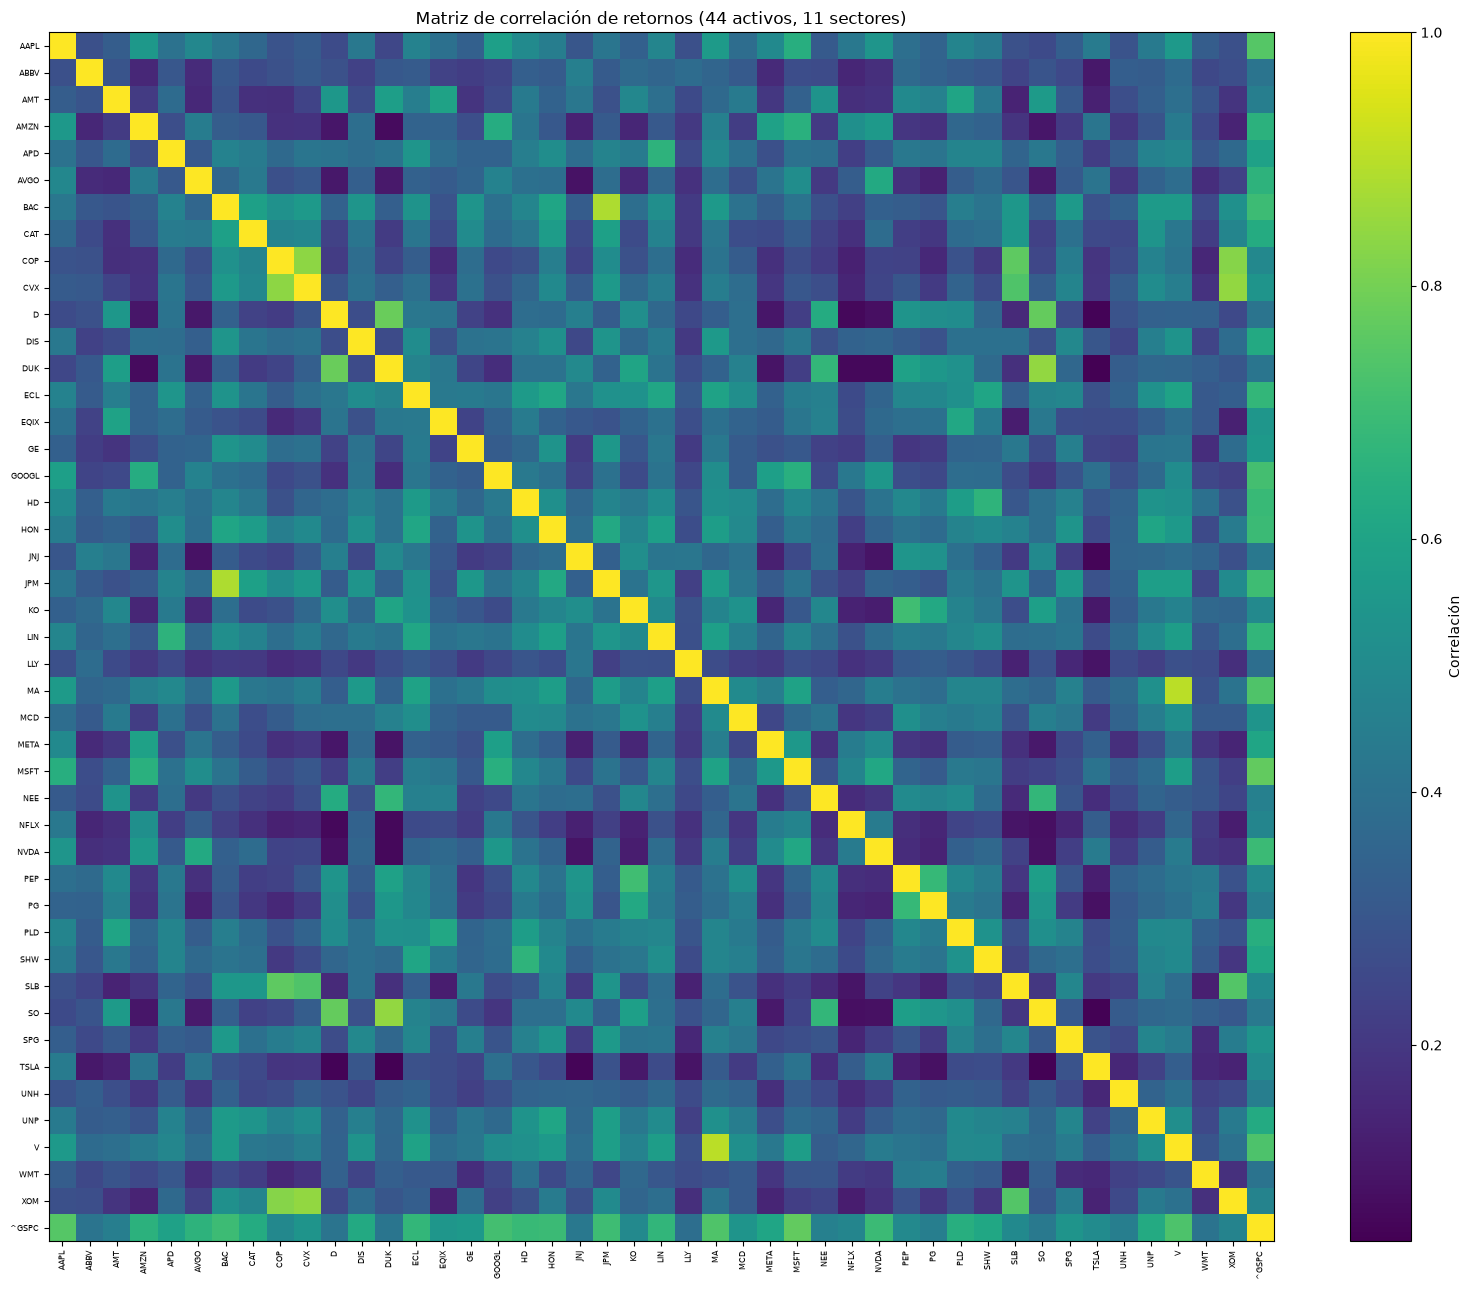

In [21]:
fig, ax = plt.subplots(figsize=(16, 13))

im = ax.imshow(correlation_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))

ax.set_xticklabels(correlation_matrix.columns, rotation=90, fontsize=6)
ax.set_yticklabels(correlation_matrix.columns, fontsize=6)

ax.set_title("Matriz de correlación de retornos (44 activos, 11 sectores)")

plt.colorbar(im, ax=ax, label="Correlación")

plt.tight_layout()

plt.savefig(RESULTS_DIR / "06_matriz_correlacion.png", dpi=300, bbox_inches="tight")
plt.show()


In [22]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(10)

MA    V        0.902580
BAC   JPM      0.880640
DUK   SO       0.845723
CVX   XOM      0.843794
COP   CVX      0.836792
      XOM      0.826988
D     DUK      0.781057
      SO       0.773879
MSFT  ^GSPC    0.769890
COP   SLB      0.764912
dtype: float64

In [23]:
corr_pairs.tail(10)

^GSPC  SLB     NaN
       SO      NaN
       SPG     NaN
       TSLA    NaN
       UNH     NaN
       UNP     NaN
       V       NaN
       WMT     NaN
       XOM     NaN
       ^GSPC   NaN
dtype: float64

### Correlación promedio dentro vs. entre sectores

Chequeo específico de este experimento: si la diversificación sectorial realmente ayuda, los activos del mismo sector deberían estar, en promedio, más correlacionados entre sí que con activos de otros sectores.

In [24]:
intra_sector_corrs = []
inter_sector_corrs = []

assets_only = [t for t in correlation_matrix.columns if t != "^GSPC"]

for i, t1 in enumerate(assets_only):
    for t2 in assets_only[i + 1:]:
        corr_value = correlation_matrix.loc[t1, t2]
        if ticker_to_sector.get(t1) == ticker_to_sector.get(t2):
            intra_sector_corrs.append(corr_value)
        else:
            inter_sector_corrs.append(corr_value)

print("Correlación promedio DENTRO del mismo sector:", round(np.mean(intra_sector_corrs), 4))
print("Correlación promedio ENTRE sectores distintos:", round(np.mean(inter_sector_corrs), 4))


Correlación promedio DENTRO del mismo sector: 0.5488
Correlación promedio ENTRE sectores distintos: 0.3425


Sharpe

In [25]:
annualized_return = returns_clean.mean() * 252
annualized_volatility = returns_clean.std() * np.sqrt(252)

sharpe = (
    annualized_return /
    annualized_volatility
)

sharpe = sharpe.sort_values(
    ascending=False
)

sharpe

LLY      1.144891
NVDA     1.126971
AVGO     0.983698
AAPL     0.948305
MSFT     0.884834
GOOGL    0.844642
TSLA     0.827409
CAT      0.803478
WMT      0.763205
^GSPC    0.721471
LIN      0.718556
ABBV     0.712127
JPM      0.686135
MA       0.684354
V        0.667093
AMZN     0.648905
KO       0.634343
JNJ      0.613982
GE       0.595101
META     0.594381
SO       0.572104
NFLX     0.552328
XOM      0.545905
EQIX     0.540162
PLD      0.529863
SHW      0.523368
UNP      0.519332
COP      0.518765
NEE      0.516425
PG       0.504002
ECL      0.480762
CVX      0.469028
DUK      0.465817
BAC      0.449973
APD      0.442237
HD       0.407325
UNH      0.398367
SPG      0.378119
HON      0.375756
MCD      0.371450
PEP      0.294300
AMT      0.292841
SLB      0.187969
D        0.172066
DIS      0.150266
dtype: float64

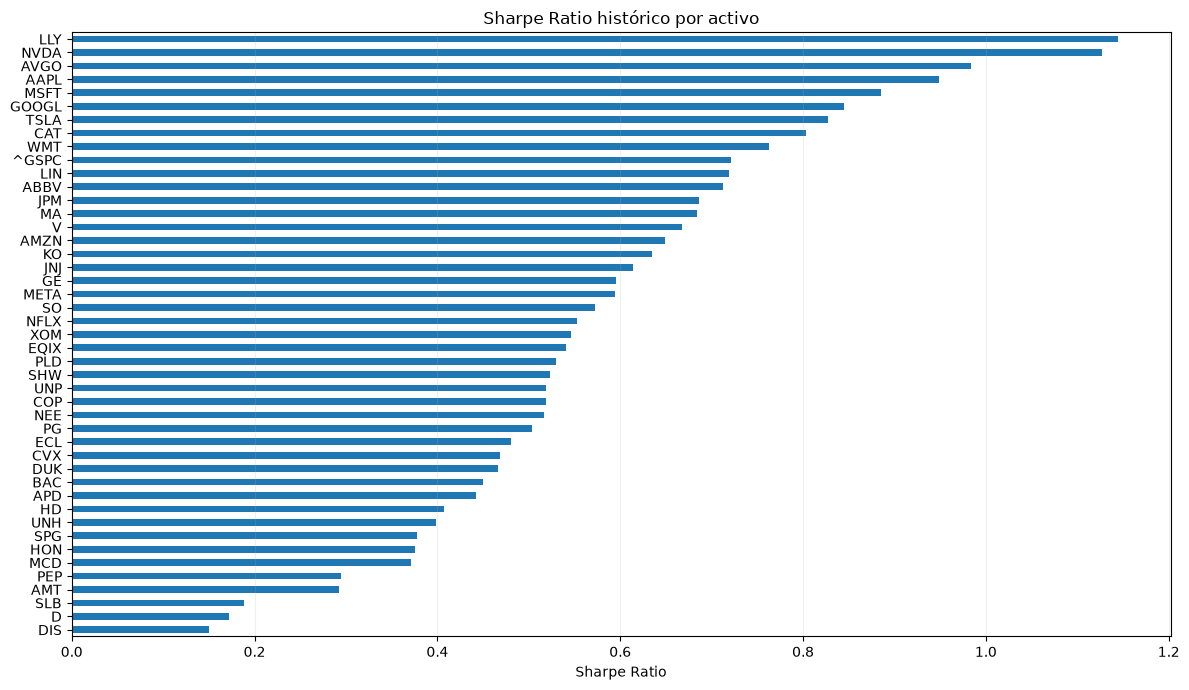

In [26]:
plt.figure(figsize=(12, 7))

sharpe.sort_values().plot(
    kind="barh"
)

plt.title("Sharpe Ratio histórico por activo")
plt.xlabel("Sharpe Ratio")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "07_sharpe_individual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Estacionalidad mensual

In [27]:
monthly_returns = (
    returns_clean
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1)
)

monthly_seasonality = monthly_returns.groupby(
    monthly_returns.index.month
).mean()

monthly_seasonality

,AAPL,ABBV,AMT,AMZN,APD,AVGO,BAC,CAT,COP,CVX,...,SLB,SO,SPG,TSLA,UNH,UNP,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
1,0.002787,-0.003436,0.001168,0.078058,0.023521,-0.014011,0.030580,0.026403,0.044224,0.022455,...,0.083561,0.013743,0.004978,0.079211,-0.018940,0.014181,0.027893,0.025889,0.063219,0.019905
2,-0.009549,0.055288,-0.013493,-0.027893,-0.051658,-0.006333,-0.005810,0.017345,0.012918,0.027812,...,0.004679,-0.013512,0.022288,-0.028648,-0.043789,0.021814,0.012926,-0.017797,0.022415,-0.010656
3,-0.002160,-0.018445,0.035413,0.016042,0.020242,-0.005157,-0.052663,0.011188,0.011856,0.024341,...,-0.048681,0.041661,-0.081876,-0.072299,0.021681,-0.010414,-0.015581,0.015385,0.012922,-0.010919
4,0.024889,-0.015747,0.007727,0.061004,0.017208,0.055350,0.022676,0.005359,0.018174,0.010044,...,-0.000268,0.029975,0.012453,0.029947,0.051431,0.001257,0.039858,0.039492,0.023489,0.022553
5,0.029422,0.002830,0.028080,0.014479,0.016193,0.075840,0.004135,0.009716,0.005085,0.000300,...,0.004510,0.004813,-0.008903,0.016347,-0.012695,0.004615,0.010987,-0.021814,-0.009748,0.018906
6,0.047202,0.019080,0.009524,0.035277,0.021490,0.040760,0.011837,0.036188,-0.004761,-0.012700,...,0.003033,-0.011382,0.036034,0.106288,0.020080,0.006569,0.010700,0.011033,0.009307,0.018757
7,0.074398,0.016479,0.033185,0.068452,0.042407,0.019775,0.048059,0.021748,0.028369,0.038274,...,0.023732,0.041799,0.026642,0.057237,0.016262,0.052324,0.025352,0.025858,0.015963,0.031217
8,0.060890,0.020967,-0.002320,0.008722,0.006777,0.002098,0.000320,-0.009320,0.025876,-0.009103,...,0.002819,-0.012223,0.011267,0.093129,0.016275,0.007555,0.023744,0.037306,-0.002851,0.013244
9,-0.016686,0.009328,-0.054944,-0.043820,-0.026062,0.009810,-0.029555,0.025690,0.002084,-0.016160,...,-0.047020,-0.012406,-0.018423,0.034501,-0.003046,-0.030677,-0.040961,0.003147,-0.000837,-0.017380


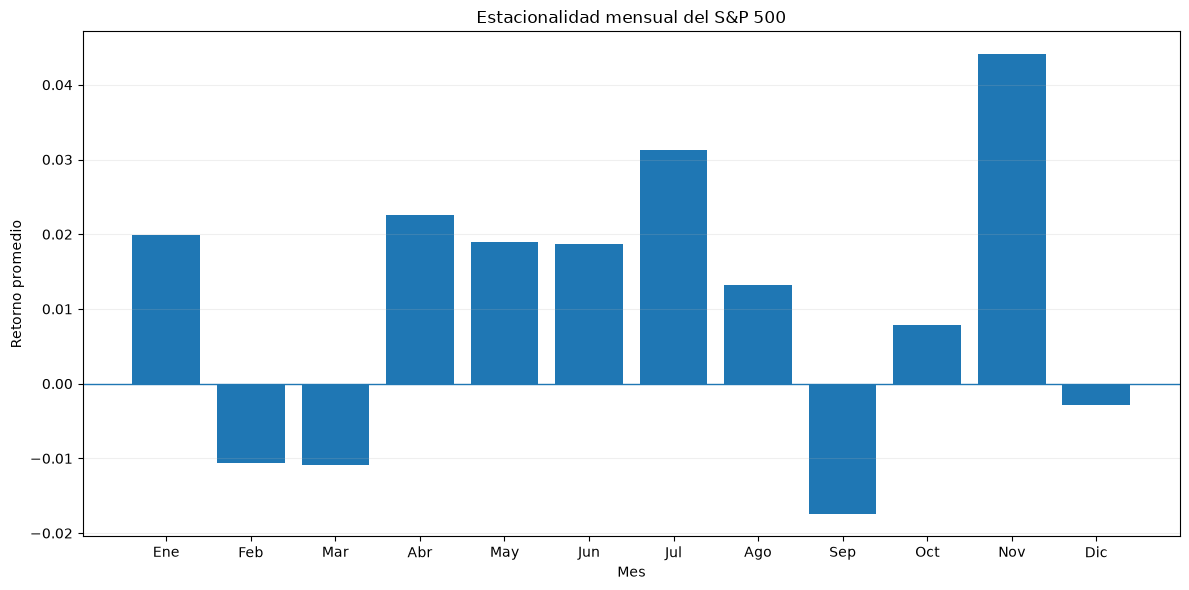

In [28]:
sp500_monthly = monthly_returns[benchmark]

monthly_avg = sp500_monthly.groupby(
    sp500_monthly.index.month
).mean()

months = [
    "Ene", "Feb", "Mar", "Abr",
    "May", "Jun", "Jul", "Ago",
    "Sep", "Oct", "Nov", "Dic"
]

plt.figure(figsize=(12, 6))

plt.bar(
    months,
    monthly_avg.values
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Estacionalidad mensual del S&P 500")
plt.xlabel("Mes")
plt.ylabel("Retorno promedio")

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "08_estacionalidad_sp500.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
summary = pd.DataFrame({
    "Annual Return": annualized_return,
    "Annual Volatility": annualized_volatility,
    "Sharpe": sharpe,
    "Cumulative Return": (
        prices.iloc[-1] /
        prices.iloc[0]
    ) - 1
})

summary = summary.sort_values(
    "Sharpe",
    ascending=False
)

summary.round(4)

,Annual Return,Annual Volatility,Sharpe,Cumulative Return
LLY,0.3645,0.3184,1.1449,14.4709
NVDA,0.5669,0.5030,1.1270,45.4468
AVGO,0.4099,0.4167,0.9837,15.7113
AAPL,0.2889,0.3046,0.9483,7.2774
MSFT,0.2575,0.2911,0.8848,5.5294
GOOGL,0.2626,0.3109,0.8446,5.4732
TSLA,0.5159,0.6235,0.8274,15.6042
CAT,0.2625,0.3267,0.8035,5.1868
WMT,0.1733,0.2271,0.7632,2.6169
^GSPC,0.1380,0.1913,0.7215,1.8383


In [30]:
summary.to_csv(
    RESULTS_DIR / "eda_summary.csv"
)